In [2]:
# Cell 1 - 라이브러리 및 DB 연결

import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = r'..\data\db\fintech.db'
conn = sqlite3.connect(DB_PATH)
print("DB 연결 완료")

DB 연결 완료


In [3]:
# Cell 2 - 테이블 기본 구조 확인

for table in ['transactions', 'users', 'cards']:
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {table}", conn)
    print(f"{table}: {count['cnt'].values[0]:,}행")

transactions: 24,386,900행
users: 2,000행
cards: 6,146행


In [4]:
# Cell 3 - transactions 샘플 확인

trans_sample = pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)
print("=== 컬럼 목록 ===")
print(trans_sample.columns.tolist())
print("\n=== 샘플 데이터 ===")
print(trans_sample)

=== 컬럼 목록 ===
['User', 'Card', 'Year', 'Month', 'Day', 'Time', 'Amount', 'Use Chip', 'Merchant Name', 'Merchant City', 'Merchant State', 'Zip', 'MCC', 'Errors?', 'Is Fraud?']

=== 샘플 데이터 ===
   User  Card  Year  Month  Day   Time   Amount           Use Chip  \
0     0     0  2002      9    1  06:21  $134.09  Swipe Transaction   
1     0     0  2002      9    1  06:42   $38.48  Swipe Transaction   
2     0     0  2002      9    2  06:22  $120.34  Swipe Transaction   
3     0     0  2002      9    2  17:45  $128.95  Swipe Transaction   
4     0     0  2002      9    3  06:23  $104.71  Swipe Transaction   

         Merchant Name  Merchant City Merchant State      Zip   MCC Errors?  \
0  3527213246127876953       La Verne             CA  91750.0  5300    None   
1  -727612092139916043  Monterey Park             CA  91754.0  5411    None   
2  -727612092139916043  Monterey Park             CA  91754.0  5411    None   
3  3414527459579106770  Monterey Park             CA  91754.0  5651    N

- Amount에 $ 붙어있음 → 전처리 필요
- Errors?가 None → 결측치 패턴 확인 필요
- Is Fraud?가 Yes/No 문자열 → 나중에 변환 필요
- 날짜가 Year/Month/Day 분리되어 있음 → 합쳐야 할 수도 있음

In [3]:
# users 테이블 구조 확인
users_sample = pd.read_sql("SELECT * FROM users LIMIT 5", conn)
print("=== 컬럼 목록 ===")
print(users_sample.columns.tolist())
print("\n=== 샘플 데이터 ===")
print(users_sample)

=== 컬럼 목록 ===
['Person', 'Current Age', 'Retirement Age', 'Birth Year', 'Birth Month', 'Gender', 'Address', 'Apartment', 'City', 'State', 'Zipcode', 'Latitude', 'Longitude', 'Per Capita Income - Zipcode', 'Yearly Income - Person', 'Total Debt', 'FICO Score', 'Num Credit Cards']

=== 샘플 데이터 ===
           Person  Current Age  Retirement Age  Birth Year  Birth Month  \
0  Hazel Robinson           53              66        1966           11   
1      Sasha Sadr           53              68        1966           12   
2      Saanvi Lee           81              67        1938           11   
3   Everlee Clark           63              63        1957            1   
4   Kyle Peterson           43              70        1976            9   

   Gender                   Address Apartment           City State  Zipcode  \
0  Female             462 Rose Lane      None       La Verne    CA    91750   
1  Female    3606 Federal Boulevard      None    Little Neck    NY    11363   
2  Female        

In [5]:
# Cell 4 - 데이터 범위 파악

range_query = """
SELECT
    MIN(Year) AS min_year,
    MAX(Year) AS max_year,
    COUNT(DISTINCT Year) AS year_count,
    COUNT(DISTINCT Month) AS month_count,
    COUNT(DISTINCT User) AS user_count,
    COUNT(DISTINCT "Merchant Name") AS merchant_count,
    COUNT(DISTINCT MCC) AS mcc_count
FROM transactions
"""
print(pd.read_sql(range_query, conn))

   min_year  max_year  year_count  month_count  user_count  merchant_count  \
0      1991      2020          30           12        2000          100343   

   mcc_count  
0        109  


- 1991~2020년, 30년치 데이터예요
- 유저 2,000명, 가맹점 100,343개, MCC 109개
- 30년이라 Cohort를 월 단위로 하면 너무 많아요 → 연도 단위로 Cohort 잡기

In [6]:
# Cell 5 - Amount 전처리 확인

amount_query = """
SELECT
    MIN(CAST(REPLACE(Amount, '$', '') AS FLOAT)) AS min_amount,
    MAX(CAST(REPLACE(Amount, '$', '') AS FLOAT)) AS max_amount,
    ROUND(AVG(CAST(REPLACE(Amount, '$', '') AS FLOAT)), 2) AS avg_amount,
    SUM(CASE WHEN CAST(REPLACE(Amount, '$', '') AS FLOAT) < 0 
        THEN 1 ELSE 0 END) AS negative_count,
    COUNT(*) AS total_count
FROM transactions
"""
print(pd.read_sql(amount_query, conn))

   min_amount  max_amount  avg_amount  negative_count  total_count
0      -500.0     12390.5       43.63         1244683     24386900


양수 = 유저가 돈을 쓴 것 (구매), 음수 = 유저한테 돈이 돌아온 것 (환불·취소)

- 최솟값이 -500달러 → 환불 거래가 1,244,683건 있음 (전체의 5.1%)
- 평균 43.63달러, 최대 12,390.5달러
- 전처리 시 환불 거래를 어떻게 처리할지 결정 필요함 

In [7]:
# Cell 6 - 사기 거래 비율

fraud_query = """
SELECT
    "Is Fraud?" AS is_fraud,
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions), 4) AS ratio
FROM transactions
GROUP BY "Is Fraud?"
"""
print(pd.read_sql(fraud_query, conn))

  is_fraud     count   ratio
0       No  24357143  99.878
1      Yes     29757   0.122


- 사기 거래 0.122% (29,757건) → 실제 금융 사기 비율이랑 유사함
- 분석에서 사기 거래 제외할지 포함할지 결정 필요함

In [8]:
# Cell 7 - Errors? 결측치 패턴

error_query = """
SELECT
    "Errors?" AS error_type,
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM transactions), 4) AS ratio
FROM transactions
GROUP BY "Errors?"
ORDER BY count DESC
"""
print(pd.read_sql(error_query, conn))

                                           error_type     count    ratio
0                                                 NaN  23998469  98.4072
1                                Insufficient Balance    242783   0.9955
2                                             Bad PIN     58918   0.2416
3                                    Technical Glitch     48157   0.1975
4                                     Bad Card Number     13321   0.0546
5                                             Bad CVV     10740   0.0440
6                                      Bad Expiration     10716   0.0439
7                                         Bad Zipcode      2079   0.0085
8                        Bad PIN,Insufficient Balance       581   0.0024
9               Insufficient Balance,Technical Glitch       457   0.0019
10                           Bad PIN,Technical Glitch       128   0.0005
11               Bad Card Number,Insufficient Balance       122   0.0005
12                       Bad CVV,Insufficient Balan

- 98.4%는 오류 없음(NaN)
- Insufficient Balance가 가장 많은 오류 (0.99%)
- 오류 거래를 정상 분석에서 제외할지 결정 필요함

>- 환불 거래 (음수 Amount)
>유저 행동 분석 관점에서는 "유저가 서비스를 이용했다"는 사실 자체는 맞음. 근데 LTV 계산할 때 >환불을 포함하면 실제 수익이 과대 계산됨. 환불도 "이 유저가 이 달에 활동했다"는 신호라서 실무에서는 LTV 계산 시에만 제외하고, >Retention·Cohort에서는 포함한다고 함. 

>- 사기 거래 (Is Fraud=Yes)
>유저 행동 분석에서는 제외하는 게 맞음. 사기 거래는 유저가 의도한 행동이 아니라서 AARRR·LTV가 >왜곡됨. 단, 나중에 A/B 테스트 가설 설정할 때 "사기 거래 많은 유저 세그먼트" 같은 방식으로 >따로 활용 가능성 있음.

>- 오류 거래 (Errors? != NaN)
>실무에서 두 가지 관점이 있음. 제외하는 관점은 오류 거래는 실제로 완료되지 않은 거래라서 >LTV·Revenue에 포함하면 안 됨. 포함하는 관점은 "유저가 결제를 시도했다"는 행동 >자체는 Funnel 분석에서 의미가 있다는 것임. 예를 들어 "Insufficient Balance 오류가 많은 >유저는 이탈 위험이 높다"는 인사이트를 뽑을 수 있음.

=> 기본 분석 테이블은 사기 거래만 제외하고, LTV 계산할 때만 추가로 환불·오류 거래도 제외하는 방식 결정

In [9]:
# Cell 8 - 전처리된 분석용 뷰 생성

create_view_query = """
CREATE VIEW IF NOT EXISTS clean_transactions AS
SELECT
    User,
    Card,
    Year,
    Month,
    Day,
    Time,
    -- Amount에서 '$' 제거 후 FLOAT 변환
    CAST(REPLACE(Amount, '$', '') AS FLOAT) AS Amount,
    "Use Chip" AS use_chip,
    "Merchant Name" AS merchant_name,
    "Merchant City" AS merchant_city,
    "Merchant State" AS merchant_state,
    Zip,
    MCC,
    "Errors?" AS errors,
    "Is Fraud?" AS is_fraud,
    -- 날짜 통합 컬럼 추가
    Year * 10000 + Month * 100 + Day AS date_int,
    Year * 100 + Month AS year_month
FROM transactions
WHERE "Is Fraud?" = 'No'
"""

conn.execute(create_view_query)
conn.commit()

# 확인
check = pd.read_sql("SELECT COUNT(*) as cnt FROM clean_transactions", conn)
print(f"clean_transactions: {check['cnt'].values[0]:,}행")
print(f"제외된 사기 거래: {24386900 - check['cnt'].values[0]:,}건")

clean_transactions: 24,357,143행
제외된 사기 거래: 29,757건


In [10]:
# Cell 9 - LTV용 뷰 (추가로 환불·오류 제외)

create_ltv_view_query = """
CREATE VIEW IF NOT EXISTS ltv_transactions AS
SELECT *
FROM clean_transactions
WHERE Amount > 0
AND errors IS NULL
"""

conn.execute(create_ltv_view_query)
conn.commit()

check_ltv = pd.read_sql("SELECT COUNT(*) as cnt FROM ltv_transactions", conn)
print(f"ltv_transactions: {check_ltv['cnt'].values[0]:,}행")

ltv_transactions: 22,723,832행


In [14]:
# Cell 10 - 결측치 확인

null_query = """
SELECT
    SUM(CASE WHEN User IS NULL THEN 1 ELSE 0 END) AS user_null,
    SUM(CASE WHEN Amount IS NULL THEN 1 ELSE 0 END) AS amount_null,
    SUM(CASE WHEN Year IS NULL THEN 1 ELSE 0 END) AS year_null,
    SUM(CASE WHEN MCC IS NULL THEN 1 ELSE 0 END) AS mcc_null,
    SUM(CASE WHEN merchant_city IS NULL THEN 1 ELSE 0 END) AS city_null,
    SUM(CASE WHEN merchant_state IS NULL THEN 1 ELSE 0 END) AS state_null,
    SUM(CASE WHEN Zip IS NULL THEN 1 ELSE 0 END) AS zip_null
FROM clean_transactions
"""
print("=== 결측치 확인 ===")
print(pd.read_sql(null_query, conn))

=== 결측치 확인 ===
   user_null  amount_null  year_null  mcc_null  city_null  state_null  \
0          0            0          0         0          0     2702472   

   zip_null  
0   2853283  


- merchant_state 270만건, Zip 285만건 결측 — 온라인 거래는 주소가 없는 경우임. 위치 기반 분석할 때 이 점 고려해야할듯
- 나머지 핵심 컬럼(User, Amount, Year, MCC)은 결측치 없음. 분석에 문제 X

In [15]:
# Cell 11 - 이상치 확인 (Amount)

outlier_query = """
SELECT
    COUNT(*) AS total,
    SUM(CASE WHEN Amount > 5000 THEN 1 ELSE 0 END) AS over_5000,
    SUM(CASE WHEN Amount > 10000 THEN 1 ELSE 0 END) AS over_10000,
    ROUND(AVG(Amount), 2) AS avg,
    -- 분포 파악용
    ROUND(MIN(Amount), 2) AS min_amount,
    MAX(Amount) AS max_amount
FROM clean_transactions
WHERE Amount > 0
"""
print("=== Amount 이상치 확인 ===")
print(pd.read_sql(outlier_query, conn))

=== Amount 이상치 확인 ===
      total  over_5000  over_10000    avg  min_amount  max_amount
0  23093385         17           1  51.42        0.01     12390.5


- 5,000달러 초과 거래 17건, 10,000달러 초과 1건 — 극단적 이상치가 거의 없음. 분석에 문제 X

In [16]:
# Cell 12 - MCC 카테고리 분석

mcc_query = """
SELECT
    MCC,
    COUNT(*) AS tx_count,
    COUNT(DISTINCT User) AS user_count,
    ROUND(AVG(Amount), 2) AS avg_amount,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM clean_transactions), 2) AS ratio
FROM clean_transactions
GROUP BY MCC
ORDER BY tx_count DESC
LIMIT 20
"""
print("=== MCC Top 20 ===")
mcc_df = pd.read_sql(mcc_query, conn)
print(mcc_df)

=== MCC Top 20 ===
     MCC  tx_count  user_count  avg_amount  ratio
0   5411   2859795        1997       26.27  11.74
1   5499   2680349        1944       10.89  11.00
2   5541   2638628        1985       20.88  10.83
3   5812   1797593        1895       26.66   7.38
4   5912   1406579        1982       46.07   5.77
5   4829   1127454        1809       90.14   4.63
6   4784   1124291         609       35.04   4.62
7   5300   1120836        1974       62.77   4.60
8   4121    980965         559       25.08   4.03
9   7538    914579        1905       53.36   3.75
10  5814    899789        1860       26.65   3.69
11  5311    880896        1961       56.68   3.62
12  4900    457616        1853      113.63   1.88
13  5310    451955        1894       41.85   1.86
14  5813    438744        1036       25.34   1.80
15  5942    416806        1853       19.41   1.71
16  4814    407064        1871      113.75   1.67
17  5211    322981        1844       45.32   1.33
18  7832    248706        1675 

=== MCC 카테고리별 거래 비중 ===
     MCC     category  tx_count  ratio
0   5411         슈퍼마켓   2859795  11.74
1   5499         식료품점   2680349  11.00
2   5541          주유소   2638628  10.83
3   5812          음식점   1797593   7.38
4   5912           약국   1406579   5.77
5   4829    금융서비스(송금)   1127454   4.63
6   4784  교통서비스(유료도로)   1124291   4.62
7   5300         대형마트   1120836   4.60
8   4121           기타    980965   4.03
9   7538           기타    914579   3.75
10  5814           기타    899789   3.69
11  5311          백화점    880896   3.62
12  4900           기타    457616   1.88
13  5310           기타    451955   1.86
14  5813           주류    438744   1.80
15  5942           기타    416806   1.71
16  4814           기타    407064   1.67
17  5211           기타    322981   1.33
18  7832           기타    248706   1.02
19  5921           기타    225346   0.93


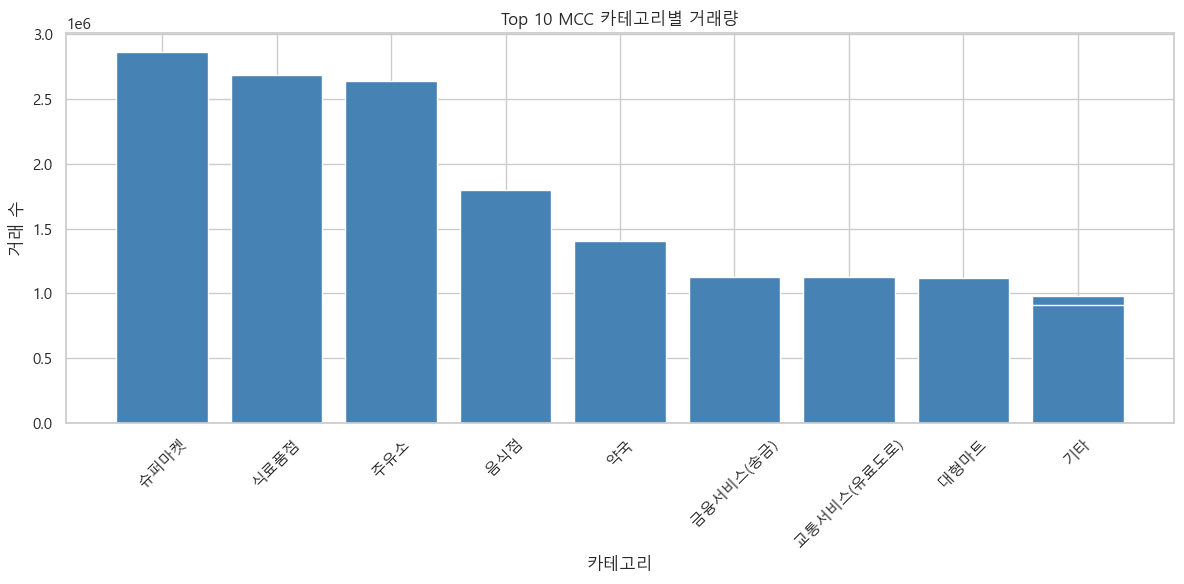

In [ ]:
# Cell 13 - MCC 카테고리 매핑
# 주요 MCC 코드에 업종명 붙이기

mcc_mapping = {
    5411: '슈퍼마켓',
    5499: '식료품점',
    4829: '금융서비스(송금)',
    4784: '교통서비스(유료도로)',
    5812: '음식점',
    5912: '약국',
    5300: '대형마트',
    5651: '의류',
    5541: '주유소',
    5732: '전자제품',
    5999: '기타소매',
    5311: '백화점',
    5661: '신발',
    5691: '의류(일반)',
    5712: '가구',
    5261: '원예',
    5251: '철물점',
    4111: '대중교통',
    5813: '주류',
    7011: '호텔',
    4411: '항공',
    5441: '사탕/과자',
    5462: '베이커리'
}

mcc_df['category'] = mcc_df['MCC'].map(mcc_mapping).fillna('기타')
print("=== MCC 카테고리별 거래 비중 ===")
print(mcc_df[['MCC', 'category', 'tx_count', 'ratio']])

######################################################################
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
######################################################################

# 시각화
plt.figure(figsize=(12, 6))
top10 = mcc_df.head(10)
plt.bar(top10['category'], top10['tx_count'], color='steelblue')
plt.title('Top 10 MCC 카테고리별 거래량')
plt.xlabel('카테고리')
plt.ylabel('거래 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'..\outputs\eda_mcc_distribution.png', dpi=150)
plt.show()

=== 대분류별 거래 비중 ===
category_large
식품/식료품    8012724
교통/자동차    5658463
음식점       1797593
의료/약국     1406579
쇼핑        1203877
금융서비스     1127454
엔터테인먼트     665512
공과금        457616
주류         438744
통신         407064
편의점        225346
Name: tx_count, dtype: int64


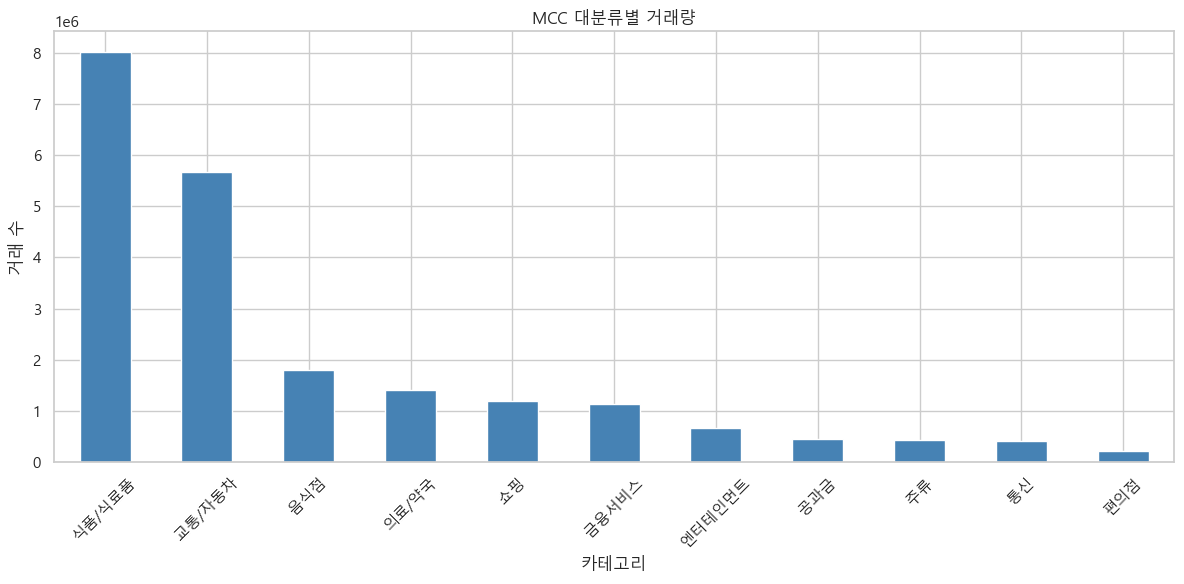

=== 세부 카테고리별 거래 비중 ===
category_detail
슈퍼마켓         2859795
식료품점         2680349
주유소          2638628
음식점          1797593
약국           1406579
금융서비스(송금)    1127454
교통(유료도로)     1124291
대형마트         1120836
택시/차량         980965
자동차수리         914579
패스트푸드         899789
백화점           880896
공과금(유틸리티)     457616
할인마트          451955
주류            438744
서점            416806
통신            407064
건축자재          322981
영화관           248706
편의점(주류)       225346
Name: tx_count, dtype: int64


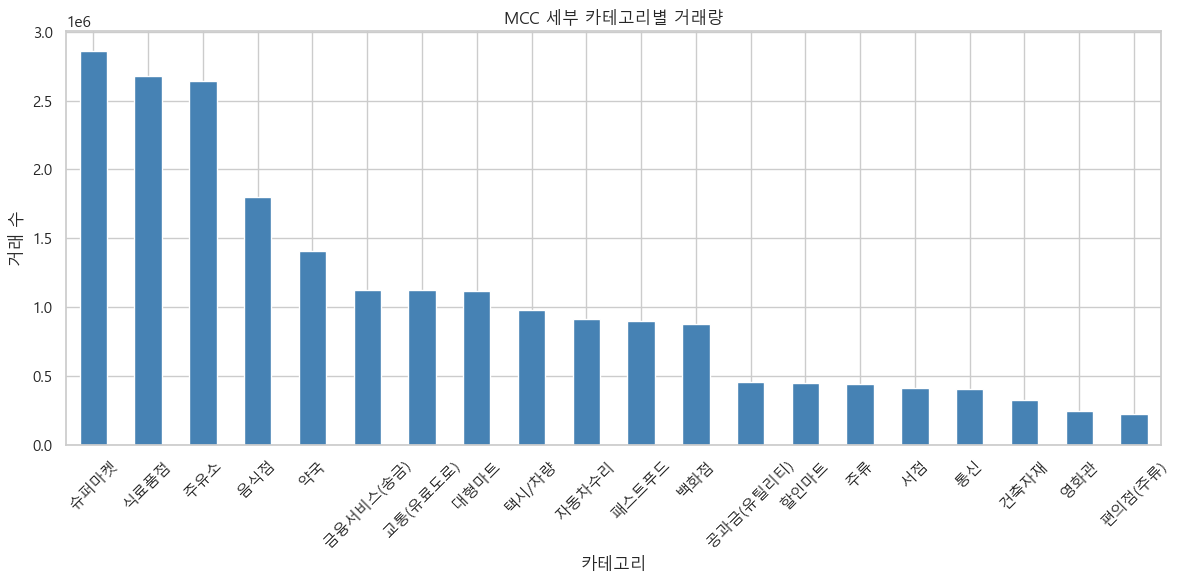

In [21]:
# Cell 14 - MCC 매핑 보완

mcc_mapping_full = {
    5411: '슈퍼마켓',
    5499: '식료품점',
    5541: '주유소',
    5812: '음식점',
    5912: '약국',
    4829: '금융서비스(송금)',
    4784: '교통(유료도로)',
    5300: '대형마트',
    4121: '택시/차량',
    7538: '자동차수리',
    5814: '패스트푸드',
    5311: '백화점',
    4900: '공과금(유틸리티)',
    5310: '할인마트',
    5813: '주류',
    5942: '서점',
    4814: '통신',
    5211: '건축자재',
    7832: '영화관',
    5921: '편의점(주류)',
    5651: '의류',
    5661: '신발',
    5691: '의류(일반)',
    5712: '가구',
    5732: '전자제품',
    5999: '기타소매',
    5261: '원예',
    5251: '철물점',
    4111: '대중교통',
    7011: '호텔',
    5441: '사탕/과자',
    5462: '베이커리',
    5411: '슈퍼마켓',
    5945: '완구/취미',
    5065: '전자부품',
    5047: '의료용품',
    7299: '기타서비스',
    5122: '의약품',
    5621: '여성의류',
    5631: '여성액세서리',
    7523: '주차',
    5411: '슈퍼마켓',
}

# 대분류 매핑 추가
mcc_category = {
    5411: '식품/식료품', 5499: '식품/식료품', 5300: '식품/식료품',
    5310: '식품/식료품', 5814: '식품/식료품', 5812: '음식점',
    5813: '음식점', 5441: '음식점', 5462: '음식점',
    5541: '교통/자동차', 4121: '교통/자동차', 7538: '교통/자동차',
    4111: '교통/자동차', 4784: '교통/자동차',
    5912: '의료/약국', 5047: '의료/약국', 5122: '의료/약국',
    4829: '금융서비스', 4900: '공과금', 4814: '통신',
    5311: '쇼핑', 5651: '쇼핑', 5661: '쇼핑', 5691: '쇼핑',
    5732: '쇼핑', 5712: '쇼핑', 5999: '쇼핑', 5211: '쇼핑',
    5942: '엔터테인먼트', 7832: '엔터테인먼트', 5945: '엔터테인먼트',
    7011: '여행/숙박',
    5921: '편의점', 5813: '주류'
}

mcc_df['category_detail'] = mcc_df['MCC'].map(mcc_mapping_full).fillna('기타')
mcc_df['category_large'] = mcc_df['MCC'].map(mcc_category).fillna('기타')

print("=== 대분류별 거래 비중 ===")
large_cat = mcc_df.groupby('category_large')['tx_count'].sum().sort_values(ascending=False)
print(large_cat)

# 대분류 시각화
plt.figure(figsize=(12, 6))
large_cat.plot(kind='bar', color='steelblue')
plt.title('MCC 대분류별 거래량')
plt.xlabel('카테고리')
plt.ylabel('거래 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'..\outputs\eda_mcc_large_category.png', dpi=150)
plt.show()

print("=== 세부 카테고리별 거래 비중 ===")
detail_cat = mcc_df.groupby('category_detail')['tx_count'].sum().sort_values(ascending=False)
print(detail_cat)

# 세부 카테고리 시각화
plt.figure(figsize=(12, 6))
detail_cat.plot(kind='bar', color='steelblue')
plt.title('MCC 세부 카테고리별 거래량')
plt.xlabel('카테고리')
plt.ylabel('거래 수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(r'..\outputs\eda_mcc_detail_category.png', dpi=150)
plt.show()

- 핵심 인사이트

식품/식료품(32.9%) + 교통/자동차(23.2%) = 전체의 56%. 일상 소비가 압도적
금융서비스(송금) 4.6%가 꽤 높아요 — 핀테크 관련 거래가 포함되어있음

In [22]:
# Cell 15 - 연도별 거래 추이

yearly_query = """
SELECT
    Year,
    COUNT(*) AS tx_count,
    COUNT(DISTINCT User) AS active_users,
    ROUND(AVG(Amount), 2) AS avg_amount,
    ROUND(SUM(Amount), 2) AS total_revenue
FROM clean_transactions
WHERE Amount > 0
GROUP BY Year
ORDER BY Year
"""
yearly = pd.read_sql(yearly_query, conn)
print(yearly)

    Year  tx_count  active_users  avg_amount  total_revenue
0   1991      1361             3       87.69      119340.21
1   1992      4619             5       70.93      327642.12
2   1993      7440            10       74.32      552951.50
3   1994     13139            18       63.82      838513.21
4   1995     19356            25       59.16     1145188.35
5   1996     28155            42       56.39     1587636.22
6   1997     46856            69       55.82     2615380.00
7   1998     73546           104       56.22     4134686.39
8   1999    111277           159       55.68     6196121.01
9   2000    166591           219       56.20     9362177.13
10  2001    241360           314       55.45    13383529.19
11  2002    329833           425       54.75    18058366.42
12  2003    438522           541       54.72    23995091.36
13  2004    561278           677       54.42    30545040.06
14  2005    703475           813       54.26    38170696.35
15  2006    856524           952       5

실제 소비 트렌드를 보기 위해서 환불을 제외한 순수 구매 금액만 확인함.
환불을 포함하면 total_revenue가 낮게 나와서 트렌드가 왜곡됨

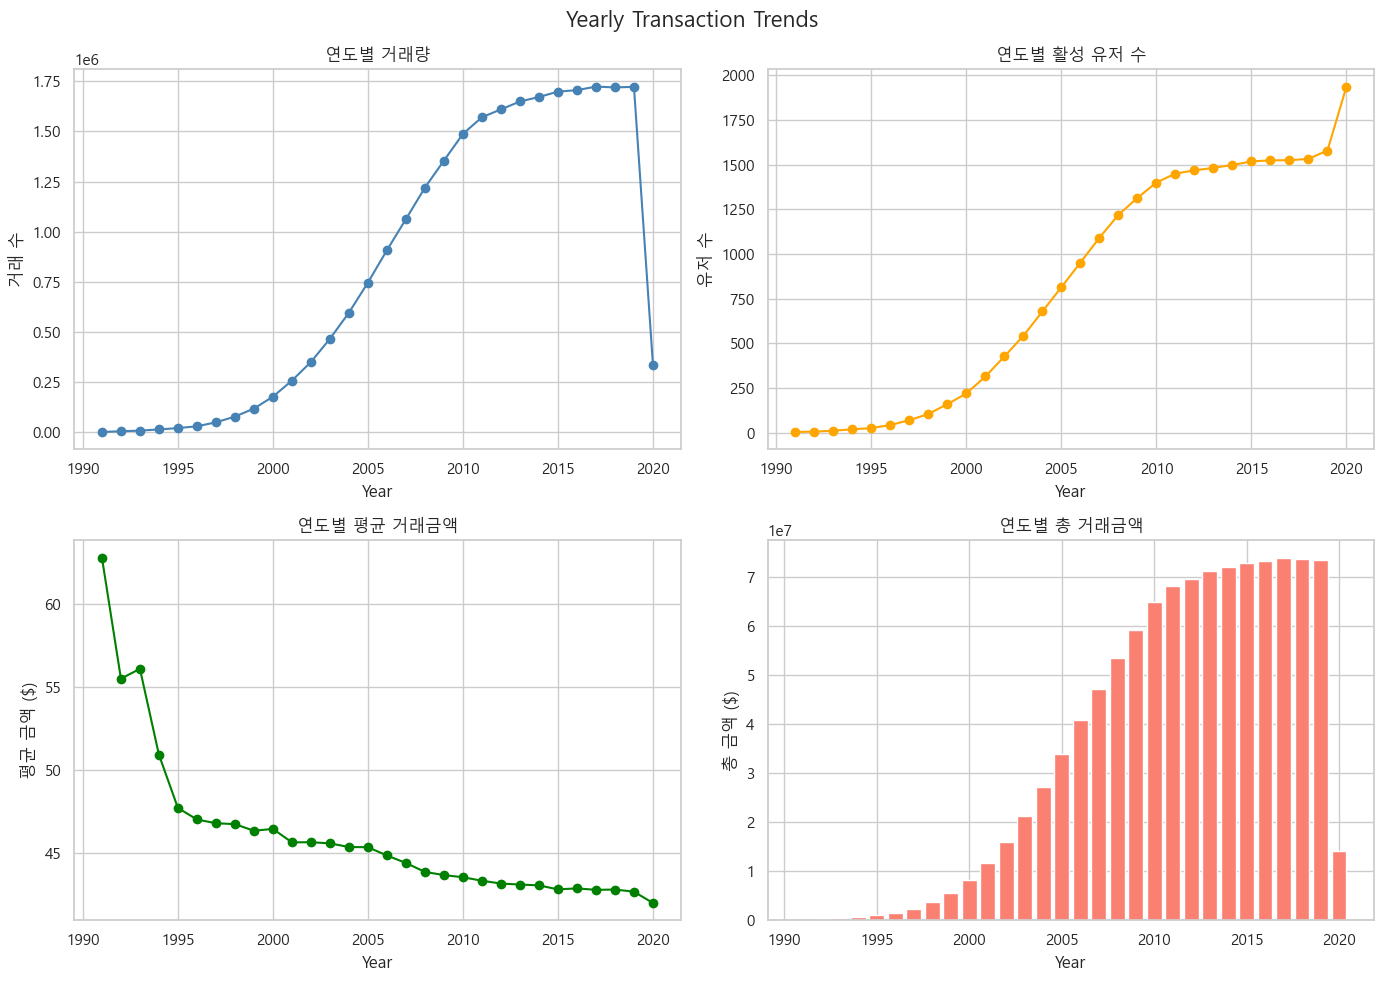

In [ ]:
# Cell 15 - 연도별 추이 시각화

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Yearly Transaction Trends', fontsize=16)

# 거래량
axes[0,0].plot(yearly['Year'], yearly['tx_count'], marker='o', color='steelblue')
axes[0,0].set_title('연도별 거래량')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('거래 수')

# 활성 유저
axes[0,1].plot(yearly['Year'], yearly['active_users'], marker='o', color='orange')
axes[0,1].set_title('연도별 활성 유저 수')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('유저 수')

# 평균 거래금액
axes[1,0].plot(yearly['Year'], yearly['avg_amount'], marker='o', color='green')
axes[1,0].set_title('연도별 평균 거래금액')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('평균 금액 ($)')

# 총 매출
axes[1,1].bar(yearly['Year'], yearly['total_revenue'], color='salmon')
axes[1,1].set_title('연도별 총 거래금액')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('총 금액 ($)')

plt.tight_layout()
plt.savefig(r'..\outputs\eda_yearly_trend.png', dpi=150)
plt.show()

- 거래량, 총 거래금액이 1991년부터 2019년까지 꾸준히 성장하다가 2020년에 급락함, 활성유저수도 급격한 변화를 보임 => 데이터가 2020년 일부만 포함되었을 가능성이 있음, 맞다면 분석에서 2020년은 제외해야 할 수도 있음
- 평균 거래금액은 1991년 약 62달러에서 2020년 약 41달러로 꾸준히 하락함. 유저가 늘어나면서 소액 거래가 많아진 걸로 보임
- 활성유저가 1991년~2002년 사이 거의 0에 가깝다가 2003년부터 급증함. cohort분석 기준 연도를 2003년 이후로 잡는 게 의미 있을 듯

In [33]:
# Cell 16 - 2020년 데이터 월 범위 확인

year_month_query= """
SELECT
    year_month,
    count(*) AS tx_count
FROM clean_transactions
WHERE year == 2020
GROUP BY year_month
"""
year_month_df = pd.read_sql(year_month_query, conn)
print(year_month_df)

   year_month  tx_count
0      202001    170731
1      202002    165769


- 데이터가 2020년 2월까지만 존재함

In [36]:
# Cell 17 - EDA 최종 정리 및 분석 전제 확정

print("=" * 50)
print("EDA 완료 - 분석 전제 조건 확정")
print("=" * 50)
print("""
[데이터 범위]
- 기간: 1991 ~ 2019 (2020년 제외 - 불완전 데이터)
- 유저: 2,000명
- 거래: 약 2,400만건 (사기 제외 후 약 2,360만건)

[전처리 규칙]
- 사기 거래 전체 제외 (clean_transactions 뷰 사용)
- LTV 계산 시 환불·오류 거래 추가 제외 (ltv_transactions 뷰 사용)
- 2020년 데이터 제외 (불완전)

[Cohort 기준]
- 연도 단위 (월 단위는 30년치라 너무 많음)
- 의미있는 구간: 2003년 이후 (활성 유저 본격 증가 시점)

[주요 카테고리]
- 식품/식료품 32.9%, 교통/자동차 23.2%가 핵심
- MCC 대분류 11개로 정리

[이상치]
- Amount 5,000달러 초과 17건 : 
  clean_transactions → 5,000달러 초과 포함 (Retention, Cohort, AARRR)
  ltv_transactions → 5,000달러 초과 제외 (LTV, Revenue 계산)
- 결측치: merchant_state·Zip에 존재 (온라인 거래)
  → 위치 기반 분석 시 온라인 거래 별도 처리
""")

EDA 완료 - 분석 전제 조건 확정

[데이터 범위]
- 기간: 1991 ~ 2019 (2020년 제외 - 불완전 데이터)
- 유저: 2,000명
- 거래: 약 2,400만건 (사기 제외 후 약 2,360만건)

[전처리 규칙]
- 사기 거래 전체 제외 (clean_transactions 뷰 사용)
- LTV 계산 시 환불·오류 거래 추가 제외 (ltv_transactions 뷰 사용)
- 2020년 데이터 제외 (불완전)

[Cohort 기준]
- 연도 단위 (월 단위는 30년치라 너무 많음)
- 의미있는 구간: 2003년 이후 (활성 유저 본격 증가 시점)

[주요 카테고리]
- 식품/식료품 32.9%, 교통/자동차 23.2%가 핵심
- MCC 대분류 11개로 정리

[이상치]
- Amount 5,000달러 초과 17건 : 
  clean_transactions → 5,000달러 초과 포함 (Retention, Cohort, AARRR)
  ltv_transactions → 5,000달러 초과 제외 (LTV, Revenue 계산)
- 결측치: merchant_state·Zip에 존재 (온라인 거래)
  → 위치 기반 분석 시 온라인 거래 별도 처리



In [37]:
# Cell 18 - 2020년 제외한 최종 분석 뷰 재생성

# 기존 뷰 삭제 후 재생성
conn.execute("DROP VIEW IF EXISTS clean_transactions")
conn.execute("DROP VIEW IF EXISTS ltv_transactions")

conn.execute("""
CREATE VIEW clean_transactions AS
SELECT
    User,
    Card,
    Year,
    Month,
    Day,
    Time,
    CAST(REPLACE(Amount, '$', '') AS FLOAT) AS Amount,
    "Use Chip" AS use_chip,
    "Merchant Name" AS merchant_name,
    "Merchant City" AS merchant_city,
    "Merchant State" AS merchant_state,
    Zip,
    MCC,
    "Errors?" AS errors,
    "Is Fraud?" AS is_fraud,
    Year * 10000 + Month * 100 + Day AS date_int,
    Year * 100 + Month AS year_month
FROM transactions
WHERE "Is Fraud?" = 'No'
AND Year < 2020
""")

conn.execute("""
CREATE VIEW ltv_transactions AS
SELECT *
FROM clean_transactions
WHERE Amount > 0
AND errors IS NULL
-- 이상치가 평균을 왜곡할 수 있어 LTV 계산에서는 제외
AND Amount <= 5000
""")

conn.commit()

# 확인
for view in ['clean_transactions', 'ltv_transactions']:
    count = pd.read_sql(f"SELECT COUNT(*) as cnt FROM {view}", conn)
    print(f"{view}: {count['cnt'].values[0]:,}행")

clean_transactions: 24,020,643행
ltv_transactions: 22,408,484행
